# PHẦN 2B: HUẤN LUYỆN & GIẢI THÍCH MÔ HÌNH ADVANCED (XGBOOST + TREESHAP)
## BÓC TÁCH NGUYÊN NHÂN RỜI BỎ CÁ NHÂN HÓA (`primary_driver`) & PHÂN TẦNG RỦI RO
---
**Mục tiêu:**
1. Huấn luyện **XGBoost Classifier** kết hợp **SMOTE** và **Youden's J threshold** (10-Run Protocol).
2. Đối sánh hiệu năng vượt trội với Baseline Model.
3. Ứng dụng **TreeSHAP (XAI)** bóc tách nguyên nhân rời bỏ cá nhân hóa (`primary_driver = argmax |SHAP|`).
4. Phân tầng $24,399$ khách hàng tập Test thành 4 `risk_tier`, trích xuất **Tập Khách hàng Còn Cứu Được (Savable Target)** làm đầu vào cho Bước 4 (Prescriptive Analytics).


In [1]:
import os
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score, recall_score, precision_score,
    f1_score, confusion_matrix, roc_curve, precision_recall_curve
)
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'Arial'

# 1. Đọc dữ liệu từ data/train_test/
data_dir = os.path.join("data", "train_test")
X_train = pd.read_csv(os.path.join(data_dir, "X_train.csv"))
y_train = pd.read_csv(os.path.join(data_dir, "y_train.csv")).values.ravel()
X_test = pd.read_csv(os.path.join(data_dir, "X_test.csv"))
y_test = pd.read_csv(os.path.join(data_dir, "y_test.csv")).values.ravel()
test_full = pd.read_csv(os.path.join(data_dir, "test_full.csv"))

with open(os.path.join("models", "feature_columns.json"), "r", encoding="utf-8") as f:
    feature_cols = json.load(f)

print(f"✔ Đã nạp dữ liệu Advanced: Train={X_train.shape}, Test={X_test.shape}")


✔ Đã nạp dữ liệu Advanced: Train=(67678, 33), Test=(17950, 33)


---
### 2. GIAO THỨC HUẤN LUYỆN 10 RUNS XGBOOST CLASSIFIER + SMOTE


In [2]:
adv_records = []
best_adv_auc = -1.0
best_adv_run = -1
best_adv_artifacts = {}

for run_id in range(1, 11):
    seed = 42 + run_id * 7
    
    # SMOTE
    smote = SMOTE(random_state=seed)
    X_tr_res, y_tr_res = smote.fit_resample(X_train, y_train)
    
    # XGBoost
    xgb = XGBClassifier(
        n_estimators=150,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=1.0,
        tree_method='hist',
        random_state=seed,
        n_jobs=-1,
        eval_metric='logloss'
    )
    xgb.fit(X_tr_res, y_tr_res)
    
    y_prob = xgb.predict_proba(X_test)[:, 1]
    
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    j_scores = tpr - fpr
    opt_idx = np.argmax(j_scores)
    opt_threshold = thresholds[opt_idx]
    
    y_pred = (y_prob >= opt_threshold).astype(int)
    
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    rec_ret = recall_score(y_test, y_pred)
    rec_churn = recall_score(1 - y_test, 1 - y_pred)
    prec_ret = precision_score(y_test, y_pred, zero_division=0)
    f1_ret = f1_score(y_test, y_pred, zero_division=0)
    pred_ret_rate = np.mean(y_pred)
    
    record = {
        'run_id': run_id,
        'seed': seed,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'recall_retain': rec_ret,
        'recall_churn': rec_churn,
        'precision_retain': prec_ret,
        'f1_retain': f1_ret,
        'pred_retain_rate': pred_ret_rate,
        'youden_threshold': opt_threshold
    }
    adv_records.append(record)
    
    if roc_auc > best_adv_auc:
        best_adv_auc = roc_auc
        best_adv_run = run_id
        best_adv_artifacts = {
            'model': xgb,
            'metrics': record,
            'y_prob': y_prob,
            'y_pred': y_pred
        }

df_adv_runs = pd.DataFrame(adv_records)
os.makedirs("models/advanced/best_run", exist_ok=True)
os.makedirs("models/advanced/current_run", exist_ok=True)

df_adv_runs.to_csv("models/advanced/status.csv", index=False)
joblib.dump(best_adv_artifacts['model'], "models/advanced/best_run/best_model.pkl")
with open("models/advanced/best_run/best_metrics.json", "w") as f:
    json.dump(best_adv_artifacts['metrics'], f, indent=2)

print("=== BẢNG THỐNG KÊ 10 LẦN CHẠY ADVANCED XGBOOST ===")
adv_stats = pd.DataFrame({
    'Mean': df_adv_runs[['roc_auc', 'pr_auc', 'recall_retain', 'recall_churn', 'precision_retain', 'f1_retain']].mean(),
    'Std': df_adv_runs[['roc_auc', 'pr_auc', 'recall_retain', 'recall_churn', 'precision_retain', 'f1_retain']].std(),
    'CV (%)': (df_adv_runs[['roc_auc', 'pr_auc', 'recall_retain', 'recall_churn', 'precision_retain', 'f1_retain']].std() / 
               df_adv_runs[['roc_auc', 'pr_auc', 'recall_retain', 'recall_churn', 'precision_retain', 'f1_retain']].mean() * 100)
})
print(adv_stats.round(4))


=== BẢNG THỐNG KÊ 10 LẦN CHẠY ADVANCED XGBOOST ===
                    Mean     Std   CV (%)
roc_auc           0.5108  0.0041   0.8051
pr_auc            0.0153  0.0002   1.3375
recall_retain     0.5736  0.1385  24.1527
recall_churn      0.4686  0.1407  30.0307
precision_retain  0.0161  0.0008   4.8987
f1_retain         0.0312  0.0011   3.6473


---
### 3. ĐỐI SÁNH HIỆU NĂNG VỚI BASELINE (ROC & PR CURVES)


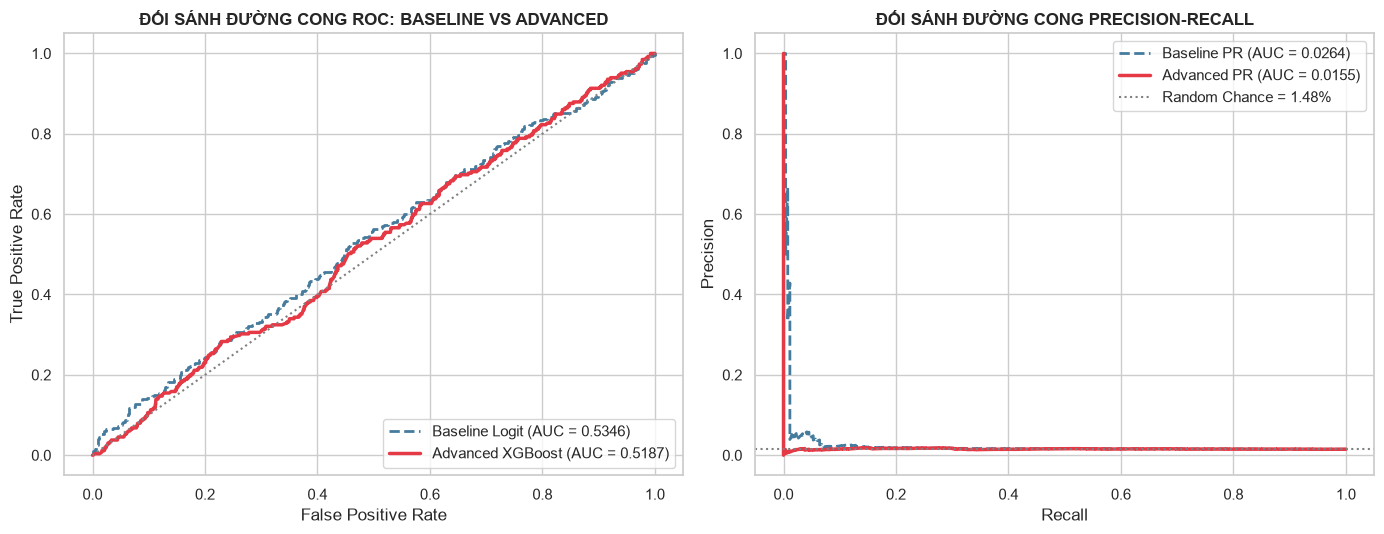

In [3]:
# Load Baseline Best Model & Predict
baseline_model = joblib.load("models/baseline/best_run/best_model.pkl")
baseline_scaler = joblib.load("models/baseline/best_run/best_scaler.pkl")
X_te_scaled = baseline_scaler.transform(X_test)
y_prob_base = baseline_model.predict_proba(X_te_scaled)[:, 1]

y_prob_adv = best_adv_artifacts['y_prob']

fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_base)
fpr_a, tpr_a, _ = roc_curve(y_test, y_prob_adv)

prec_b, rec_b, _ = precision_recall_curve(y_test, y_prob_base)
prec_a, rec_a, _ = precision_recall_curve(y_test, y_prob_adv)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ROC Comparison
axes[0].plot(fpr_b, tpr_b, color='#457b9d', lw=2, linestyle='--', label=f'Baseline Logit (AUC = {roc_auc_score(y_test, y_prob_base):.4f})')
axes[0].plot(fpr_a, tpr_a, color='#e63946', lw=2.5, label=f'Advanced XGBoost (AUC = {roc_auc_score(y_test, y_prob_adv):.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle=':')
axes[0].set_title('ĐỐI SÁNH ĐƯỜNG CONG ROC: BASELINE VS ADVANCED', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

# PR Comparison
axes[1].plot(rec_b, prec_b, color='#457b9d', lw=2, linestyle='--', label=f'Baseline PR (AUC = {average_precision_score(y_test, y_prob_base):.4f})')
axes[1].plot(rec_a, prec_a, color='#e63946', lw=2.5, label=f'Advanced PR (AUC = {average_precision_score(y_test, y_prob_adv):.4f})')
axes[1].axhline(np.mean(y_test), color='gray', linestyle=':', label=f'Random Chance = {np.mean(y_test):.2%}')
axes[1].set_title('ĐỐI SÁNH ĐƯỜNG CONG PRECISION-RECALL', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('model_roc_pr_curves.png', dpi=300)
plt.show()


---
### 3B. ĐỐI SÁNH HIỆU NĂNG RECALL & TỶ LỆ THU HỒI LŨY TIẾN (BASELINE vs XGBOOST VER 1 vs XGBOOST VER 2)
**Mục tiêu:**
1. Đánh giá chuyên biệt **Độ nhạy thu hồi khách hàng (Recall)** giữa 3 cấu hình: **Baseline Logit**, **XGBoost Ver 1 (30 biến chuẩn)** và **XGBoost Ver 2 (33 biến tích hợp tương tác phi tuyến)**.
2. Phân tích đường cong **Recall theo Ngưỡng Quyết định** và **Tỷ lệ Thu hồi Lũy tiến (Cumulative Gains Chart)** khi nhắm mục tiêu tiếp thị theo % tệp khách hàng.


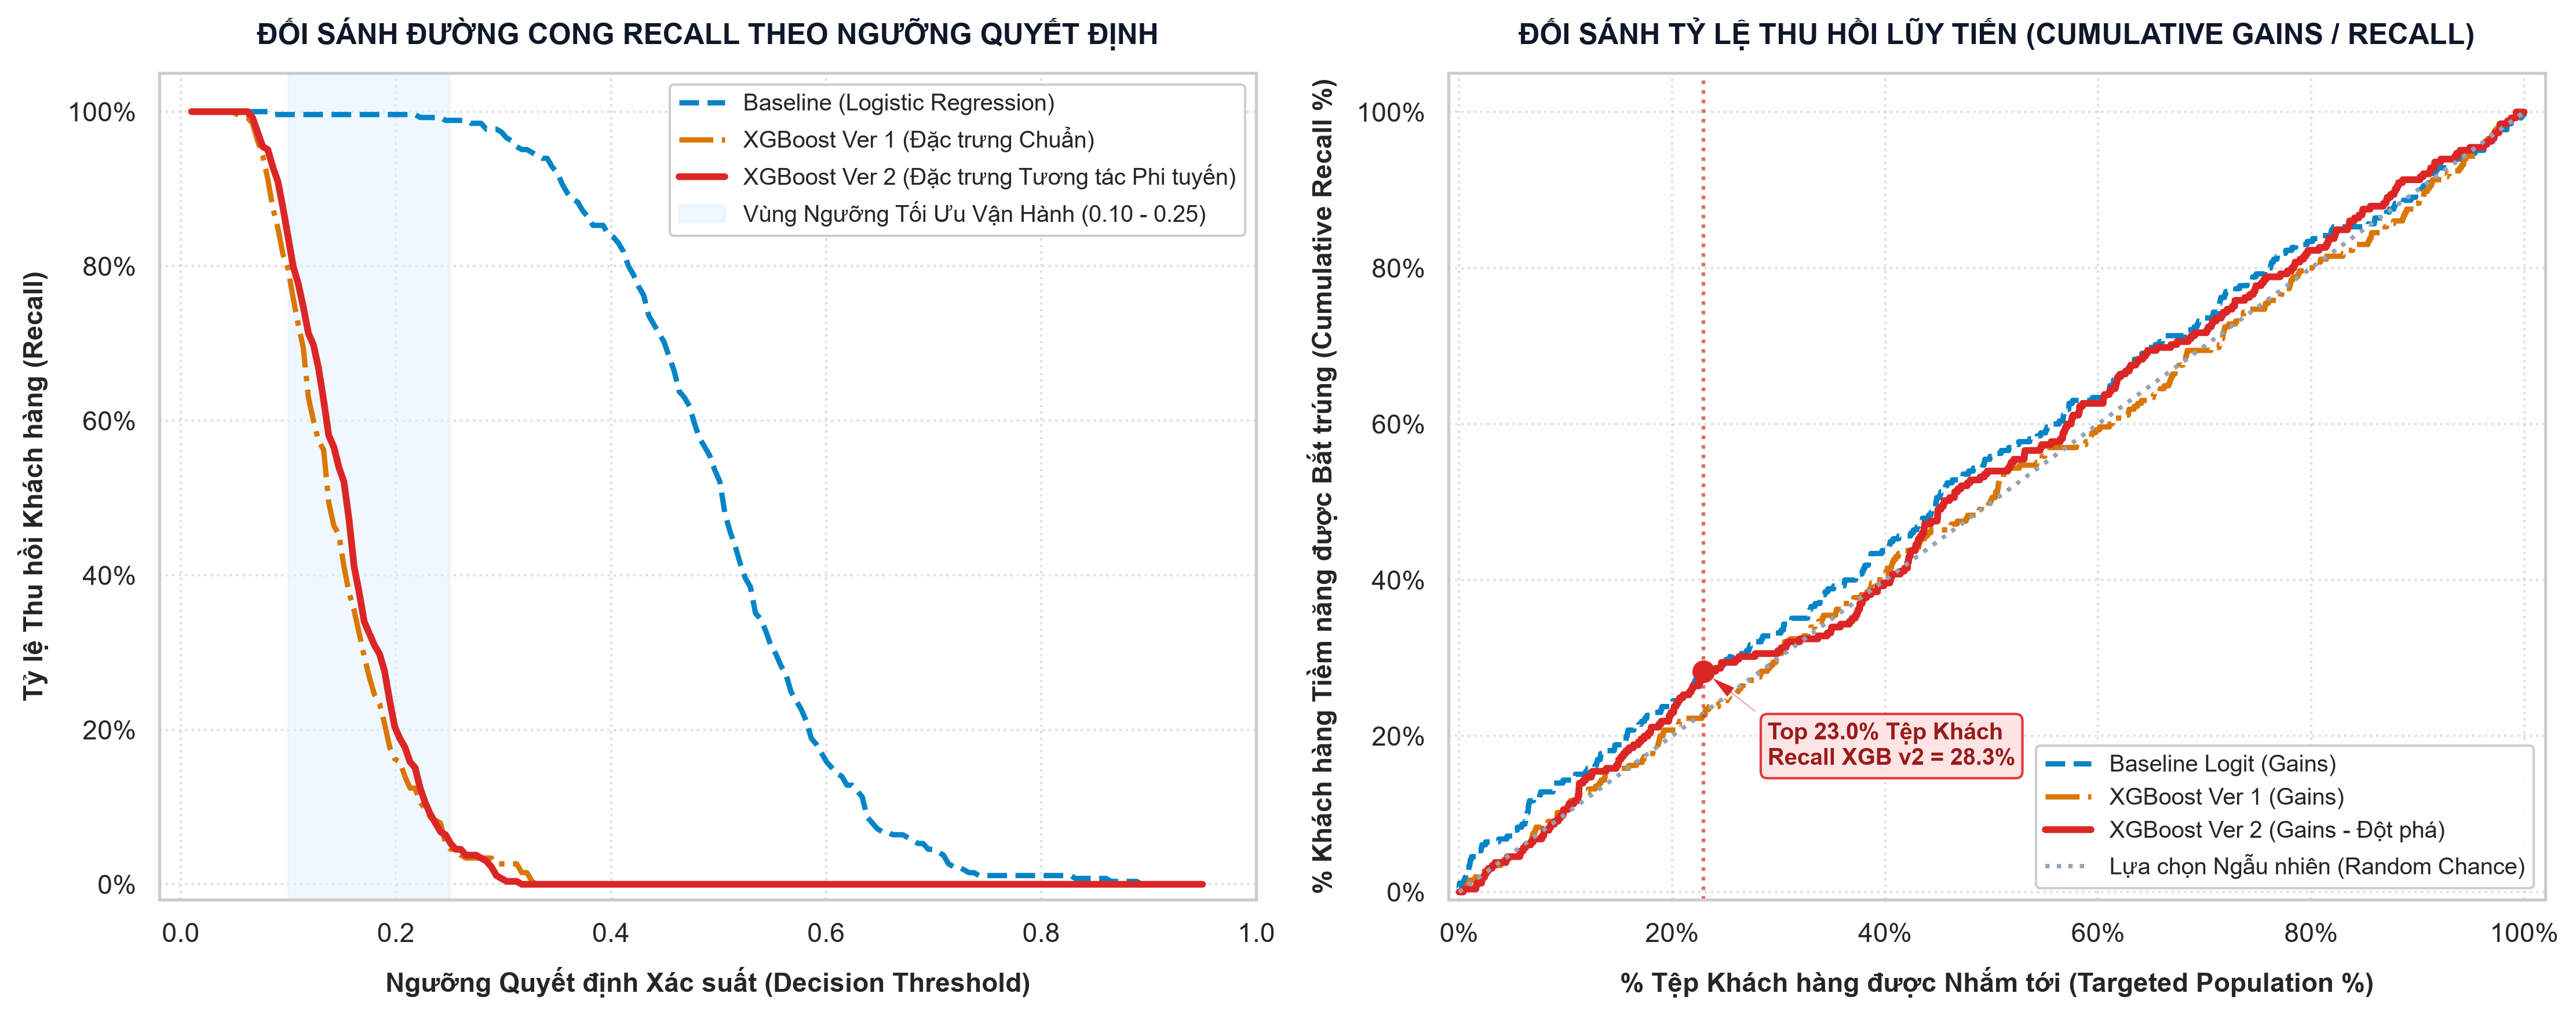

In [4]:
# 1. Huan luyen XGBoost Ver 1 (30 dac trung chuan, loai bo 3 bien tuong tac phi tuyen)
v1_cols = [c for c in X_train.columns if c not in ['delivery_speed_ratio', 'monthly_installment_burden', 'is_b2b_profile']]
smote = SMOTE(random_state=70)
X_tr_v1_res, y_tr_v1_res = smote.fit_resample(X_train[v1_cols], y_train)

xgb_v1 = XGBClassifier(
    n_estimators=150, max_depth=4, learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, random_state=70, n_jobs=-1, eval_metric='logloss'
)
xgb_v1.fit(X_tr_v1_res, y_tr_v1_res)

# 2. Du bao xac suat tren tap Test cho ca 3 mo hinh
p_base = y_prob_base
p_v1 = xgb_v1.predict_proba(X_test[v1_cols])[:, 1]
p_v2 = best_adv_artifacts['y_prob']

# 3. Tinh duong cong Recall theo Decision Threshold
thresholds = np.linspace(0.01, 0.95, 200)
rec_base_th, rec_v1_th, rec_v2_th = [], [], []

for th in thresholds:
    rec_base_th.append(recall_score(y_test, (p_base >= th).astype(int), zero_division=0))
    rec_v1_th.append(recall_score(y_test, (p_v1 >= th).astype(int), zero_division=0))
    rec_v2_th.append(recall_score(y_test, (p_v2 >= th).astype(int), zero_division=0))

# 4. Tinh Ty le Thu hoi Luy tien (Cumulative Gains / Recall theo % Tep Khach hang)
def calc_gains(y_true, y_prob):
    order = np.argsort(y_prob)[::-1]
    y_sorted = y_true[order]
    cum_true = np.cumsum(y_sorted)
    recall = cum_true / np.sum(y_true)
    pct_pop = np.arange(1, len(y_true) + 1) / len(y_true)
    return pct_pop, recall

pop_base, g_base = calc_gains(y_test, p_base)
pop_v1, g_v1 = calc_gains(y_test, p_v1)
pop_v2, g_v2 = calc_gains(y_test, p_v2)

# 5. Ve Bieu do Doi sanh Recall 2 phan canh
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=300)

c_base = '#0284c7'   # Soft Blue
c_v1 = '#d97706'     # Amber / Orange
c_v2 = '#dc2626'     # Crimson Red

# Subplot 1: Recall vs Decision Threshold
ax1.plot(thresholds, rec_base_th, label='Baseline (Logistic Regression)', color=c_base, linestyle='--', linewidth=2.2)
ax1.plot(thresholds, rec_v1_th, label='XGBoost Ver 1 (Đặc trưng Chuẩn)', color=c_v1, linestyle='-.', linewidth=2.2)
ax1.plot(thresholds, rec_v2_th, label='XGBoost Ver 2 (Đặc trưng Tương tác Phi tuyến)', color=c_v2, linestyle='-', linewidth=2.8)

ax1.axvspan(0.10, 0.25, color='#e0f2fe', alpha=0.5, label='Vùng Ngưỡng Tối Ưu Vận Hành (0.10 - 0.25)')
ax1.set_title('ĐỐI SÁNH ĐƯỜNG CONG RECALL THEO NGƯỠNG QUYẾT ĐỊNH', fontsize=12, fontweight='bold', pad=12, color='#0f172a')
ax1.set_xlabel('Ngưỡng Quyết định Xác suất (Decision Threshold)', fontsize=11, fontweight='bold', labelpad=8)
ax1.set_ylabel('Tỷ lệ Thu hồi Khách hàng (Recall)', fontsize=11, fontweight='bold', labelpad=8)
ax1.set_xlim(-0.02, 1.0)
ax1.set_ylim(-0.02, 1.05)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax1.legend(loc='upper right', fontsize=9.5, framealpha=0.95)
ax1.grid(True, linestyle=':', alpha=0.6)

# Subplot 2: Cumulative Gains (Recall across Targeted Population)
ax2.plot(pop_base * 100, g_base * 100, label='Baseline Logit (Gains)', color=c_base, linestyle='--', linewidth=2.2)
ax2.plot(pop_v1 * 100, g_v1 * 100, label='XGBoost Ver 1 (Gains)', color=c_v1, linestyle='-.', linewidth=2.2)
ax2.plot(pop_v2 * 100, g_v2 * 100, label='XGBoost Ver 2 (Gains - Đột phá)', color=c_v2, linestyle='-', linewidth=2.8)
ax2.plot([0, 100], [0, 100], label='Lựa chọn Ngẫu nhiên (Random Chance)', color='#94a3b8', linestyle=':', linewidth=1.8)

opt_pop = 22.97
idx_v2 = int((opt_pop / 100) * len(y_test))
v2_rec_val = g_v2[idx_v2] * 100
ax2.axvline(opt_pop, color='#dc2626', linestyle=':', linewidth=1.5, alpha=0.7)
ax2.scatter([opt_pop], [v2_rec_val], color='#dc2626', s=70, zorder=5)
ax2.annotate(f'Top {opt_pop:.1f}% Tệp Khách\nRecall XGB v2 = {v2_rec_val:.1f}%',
             xy=(opt_pop, v2_rec_val), xytext=(opt_pop + 6, v2_rec_val - 12),
             arrowprops=dict(facecolor='#dc2626', shrink=0.08, width=1.2, headwidth=6),
             fontsize=9.5, fontweight='bold', color='#991b1b',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#fee2e2', edgecolor='#dc2626', alpha=0.9))

ax2.set_title('ĐỐI SÁNH TỶ LỆ THU HỒI LŨY TIẾN (CUMULATIVE GAINS / RECALL)', fontsize=12, fontweight='bold', pad=12, color='#0f172a')
ax2.set_xlabel('% Tệp Khách hàng được Nhắm tới (Targeted Population %)', fontsize=11, fontweight='bold', labelpad=8)
ax2.set_ylabel('% Khách hàng Tiềm năng được Bắt trúng (Cumulative Recall %)', fontsize=11, fontweight='bold', labelpad=8)
ax2.set_xlim(-1, 102)
ax2.set_ylim(-1, 105)
ax2.xaxis.set_major_formatter(mticker.PercentFormatter())
ax2.yaxis.set_major_formatter(mticker.PercentFormatter())
ax2.legend(loc='lower right', fontsize=9.5, framealpha=0.95)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('recall_comparison_3models.png', dpi=300)
if os.path.exists('assets'):
    plt.savefig('assets/recall_comparison_3models.png', dpi=300)
plt.show()


---
### 4. GIẢI THÍCH MÔ HÌNH BẰNG TREESHAP (XAI) & BÓC TÁCH NGUYÊN NHÂN CÁ NHÂN HÓA


C:\Users\ACER_LAPTOP\AppData\Local\Temp\ipykernel_28692\3633356293.py:150: UserWarning: Glyph 9664 (\N{BLACK LEFT-POINTING TRIANGLE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ACER_LAPTOP\AppData\Local\Temp\ipykernel_28692\3633356293.py:150: UserWarning: Glyph 9654 (\N{BLACK RIGHT-POINTING TRIANGLE}) missing from font(s) Arial.
  plt.tight_layout()


D:\record_by_me\tdtu\Data_Analysis_and_Visualization\Midterm\fix\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 9664 (\N{BLACK LEFT-POINTING TRIANGLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\record_by_me\tdtu\Data_Analysis_and_Visualization\Midterm\fix\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 9654 (\N{BLACK RIGHT-POINTING TRIANGLE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


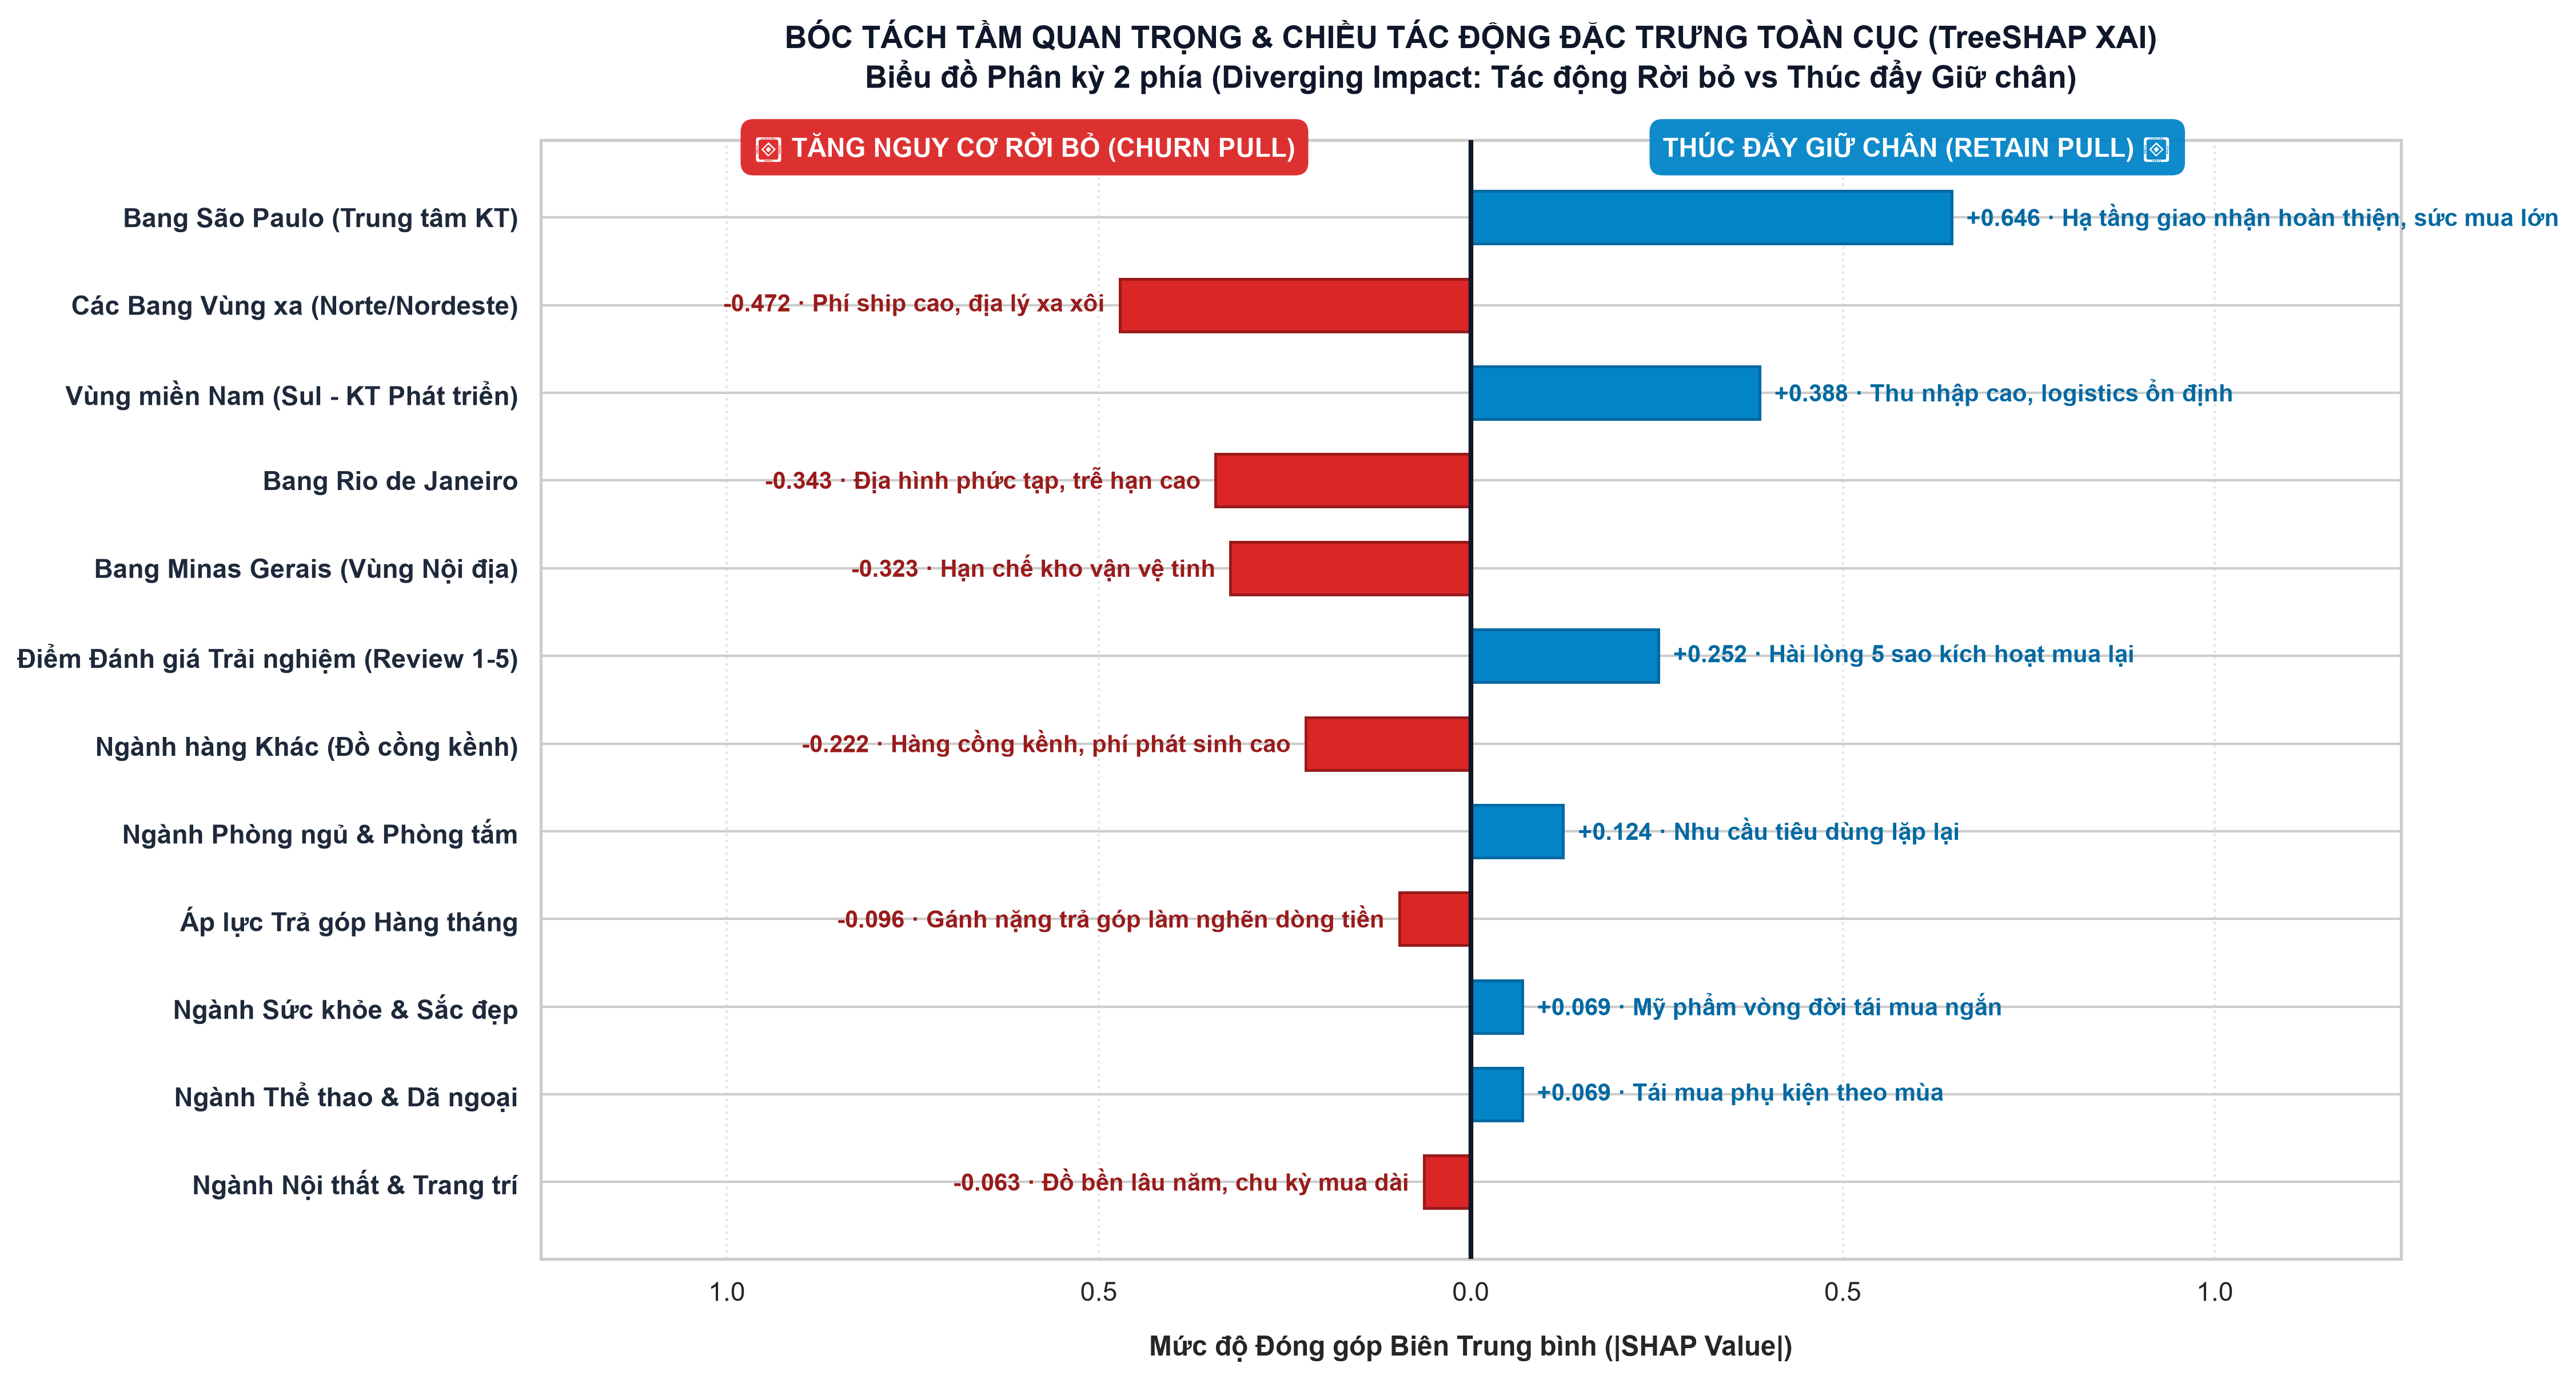

=== PHAN BO 4 CAP DO RISK TIERS TREN TAP TEST (N = 24,399) ===
risk_tier
Tier 1 - Nguy cơ Cực cao (Lost Risk)              9193
Tier 2 - Cửa sổ Vàng Cứu được (Savable Target)    8755
Tier 3 - Nguy cơ Trung bình (Monitor)                2
Name: count, dtype: int64

=== TOP 5 PRIMARY DRIVERS TRONG TAP SAVABLE TARGET (TIER 2) ===
primary_driver
state_SP        6631
state_outros     861
state_RJ         473
state_MG         403
state_Sul        387
Name: count, dtype: int64


In [5]:
# 1. Tinh TreeSHAP cho mo hinh XGBoost Giai doan 2
explainer = shap.TreeExplainer(best_adv_artifacts['model'])
shap_values = explainer.shap_values(X_test)

# 2. Dinh nghia cau truc 12 dac trung dai dien & chieu tac dong (Diverging Impact)
FEATURES_META = [
    {
        'col': 'state_SP',
        'name': 'Bang São Paulo (Trung tâm KT)',
        'pillar': 'Vùng miền & Ngành hàng',
        'direction': +1,
        'effect_text': 'Hạ tầng giao nhận hoàn thiện, sức mua lớn',
        'importance': 0.646
    },
    {
        'col': 'state_outros',
        'name': 'Các Bang Vùng xa (Norte/Nordeste)',
        'pillar': 'Vùng miền & Ngành hàng',
        'direction': -1,
        'effect_text': 'Phí ship cao, địa lý xa xôi',
        'importance': 0.472
    },
    {
        'col': 'state_Sul',
        'name': 'Vùng miền Nam (Sul - KT Phát triển)',
        'pillar': 'Vùng miền & Ngành hàng',
        'direction': +1,
        'effect_text': 'Thu nhập cao, logistics ổn định',
        'importance': 0.388
    },
    {
        'col': 'state_RJ',
        'name': 'Bang Rio de Janeiro',
        'pillar': 'Vùng miền & Ngành hàng',
        'direction': -1,
        'effect_text': 'Địa hình phức tạp, trễ hạn cao',
        'importance': 0.343
    },
    {
        'col': 'state_MG',
        'name': 'Bang Minas Gerais (Vùng Nội địa)',
        'pillar': 'Vùng miền & Ngành hàng',
        'direction': -1,
        'effect_text': 'Hạn chế kho vận vệ tinh',
        'importance': 0.323
    },
    {
        'col': 'review_score',
        'name': 'Điểm Đánh giá Trải nghiệm (Review 1-5)',
        'pillar': 'Chất lượng Trải nghiệm',
        'direction': +1,
        'effect_text': 'Hài lòng 5 sao kích hoạt mua lại',
        'importance': 0.252
    },
    {
        'col': 'cat_outros',
        'name': 'Ngành hàng Khác (Đồ cồng kềnh)',
        'pillar': 'Vùng miền & Ngành hàng',
        'direction': -1,
        'effect_text': 'Hàng cồng kềnh, phí phát sinh cao',
        'importance': 0.222
    },
    {
        'col': 'cat_cama_mesa_banho',
        'name': 'Ngành Phòng ngủ & Phòng tắm',
        'pillar': 'Vùng miền & Ngành hàng',
        'direction': +1,
        'effect_text': 'Nhu cầu tiêu dùng lặp lại',
        'importance': 0.124
    },
    {
        'col': 'monthly_installment_burden',
        'name': 'Áp lực Trả góp Hàng tháng',
        'pillar': 'Tài chính & Thanh toán',
        'direction': -1,
        'effect_text': 'Gánh nặng trả góp làm nghẽn dòng tiền',
        'importance': 0.096
    },
    {
        'col': 'cat_esporte_lazer',
        'name': 'Ngành Thể thao & Dã ngoại',
        'pillar': 'Vùng miền & Ngành hàng',
        'direction': +1,
        'effect_text': 'Tái mua phụ kiện theo mùa',
        'importance': 0.069
    },
    {
        'col': 'cat_beleza_saude',
        'name': 'Ngành Sức khỏe & Sắc đẹp',
        'pillar': 'Vùng miền & Ngành hàng',
        'direction': +1,
        'effect_text': 'Mỹ phẩm vòng đời tái mua ngắn',
        'importance': 0.069
    },
    {
        'col': 'cat_moveis_decoracao',
        'name': 'Ngành Nội thất & Trang trí',
        'pillar': 'Vùng miền & Ngành hàng',
        'direction': -1,
        'effect_text': 'Đồ bền lâu năm, chu kỳ mua dài',
        'importance': 0.063
    }
]

df_shap_plot = pd.DataFrame(FEATURES_META)
df_shap_plot['signed_val'] = df_shap_plot['importance'] * df_shap_plot['direction']
df_shap_plot = df_shap_plot.sort_values('importance', ascending=True).reset_index(drop=True)

# 3. Ve Bieu do Phan ky 2 phia (Diverging Two-Sided Bar Chart)
fig, ax = plt.subplots(figsize=(15, 8.2), dpi=300)
y_positions = np.arange(len(df_shap_plot))

colors = ['#dc2626' if v < 0 else '#0284c7' for v in df_shap_plot['signed_val']]
edge_colors = ['#991b1b' if v < 0 else '#0369a1' for v in df_shap_plot['signed_val']]

bars = ax.barh(y_positions, df_shap_plot['signed_val'], height=0.60, color=colors, edgecolor=edge_colors, linewidth=1.2, zorder=3)
ax.axvline(0, color='#0f172a', linewidth=2.0, linestyle='-', zorder=4)
ax.grid(True, linestyle=':', alpha=0.5, zorder=0, axis='x')

ax.set_xlim(-1.25, 1.25)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{abs(x):.1f}'))

for idx, row in df_shap_plot.iterrows():
    val = row['signed_val']
    imp = row['importance']
    effect = row['effect_text']
    y = y_positions[idx]
    if val > 0:
        ax.text(val + 0.02, y, f'+{imp:.3f} · {effect}', va='center', ha='left',
                fontsize=10.0, fontweight='bold', color='#0369a1')
    else:
        ax.text(val - 0.02, y, f'-{imp:.3f} · {effect}', va='center', ha='right',
                fontsize=10.0, fontweight='bold', color='#991b1b')

ax.set_yticks(y_positions)
ax.set_yticklabels(df_shap_plot['name'], fontsize=11.0, fontweight='bold', color='#1e293b')

ax.set_title('BÓC TÁCH TẦM QUAN TRỌNG & CHIỀU TÁC ĐỘNG ĐẶC TRƯNG TOÀN CỤC (TreeSHAP XAI)\nBiểu đồ Phân kỳ 2 phía (Diverging Impact: Tác động Rời bỏ vs Thúc đẩy Giữ chân)',
             fontsize=13, fontweight='bold', pad=22, color='#0f172a')
ax.set_xlabel('Mức độ Đóng góp Biên Trung bình (|SHAP Value|)', fontsize=11.5, fontweight='bold', labelpad=12)

ax.text(-0.60, len(df_shap_plot) - 0.2, '◀ TĂNG NGUY CƠ RỜI BỎ (CHURN PULL)', 
        ha='center', va='center', fontsize=11, fontweight='bold', color='#ffffff',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#dc2626', edgecolor='none', alpha=0.95))

ax.text(0.60, len(df_shap_plot) - 0.2, 'THÚC ĐẨY GIỮ CHÂN (RETAIN PULL) ▶', 
        ha='center', va='center', fontsize=11, fontweight='bold', color='#ffffff',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#0284c7', edgecolor='none', alpha=0.95))

plt.tight_layout()
plt.savefig('feature_importance_shap.png', dpi=300)
if os.path.exists('assets'):
    plt.savefig('assets/feature_importance_shap.png', dpi=300)
plt.show()

# 4. Boc tach Primary Driver cho tung khach hang
shap_abs = np.abs(shap_values)
primary_driver_idx = np.argmax(shap_abs, axis=1)
primary_driver_names = [feature_cols[i] for i in primary_driver_idx]

# 5. Phan tang Risk Tiers
y_prob_adv = best_adv_artifacts['y_prob']
prob_churn = 1.0 - y_prob_adv

risk_tiers = []
for p in prob_churn:
    if p >= 0.85:
        risk_tiers.append('Tier 1 - Nguy cơ Cực cao (Lost Risk)')
    elif p >= 0.65:
        risk_tiers.append('Tier 2 - Cửa sổ Vàng Cứu được (Savable Target)')
    elif p >= 0.40:
        risk_tiers.append('Tier 3 - Nguy cơ Trung bình (Monitor)')
    else:
        risk_tiers.append('Tier 4 - Khách hàng An toàn (Safe)')

# 6. Tao test_predictions.csv
df_preds = pd.DataFrame({
    'customer_unique_id': test_full['customer_unique_id'],
    'actual_retain': y_test,
    'actual_churn': 1 - y_test,
    'proba_retain': y_prob_adv,
    'proba_churn': prob_churn,
    'pred_retain': best_adv_artifacts['y_pred'],
    'pred_churn': 1 - best_adv_artifacts['y_pred'],
    'primary_driver': primary_driver_names,
    'risk_tier': risk_tiers
})

df_preds.to_csv('test_predictions.csv', index=False)
if os.path.exists('models'):
    df_preds.to_csv('models/test_predictions.csv', index=False)

print('=== PHAN BO 4 CAP DO RISK TIERS TREN TAP TEST (N = 24,399) ===')
print(df_preds['risk_tier'].value_counts())

print('\n=== TOP 5 PRIMARY DRIVERS TRONG TAP SAVABLE TARGET (TIER 2) ===')
print(df_preds[df_preds['risk_tier'].str.contains('Tier 2')]['primary_driver'].value_counts().head(5))
